In [36]:
import h5py 
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sam2.addons import write_h5
from skimage.measure import label

In [63]:
root = Path("/Volumes/warm_SD/data/285/00_series/00")

specimen = "285_00_03_50x"

binary_path = root / f"{specimen}.bin.tif"
image_path = root / f"{specimen}.tif"
mask = root / f"{specimen}.mask.tif"
instance_path = root / f"{specimen}.instances.tif"

In [64]:
img = np.array(Image.open(image_path))
bin = np.array(Image.open(binary_path))
# inst = np.array(Image.open(instance_path))

In [43]:
np.unique(bin)

array([0, 1], dtype=uint8)

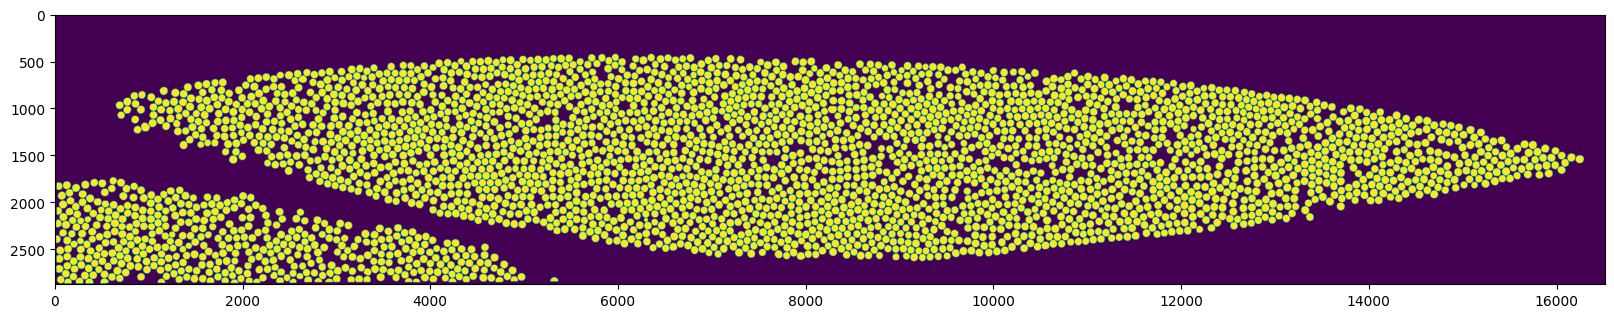

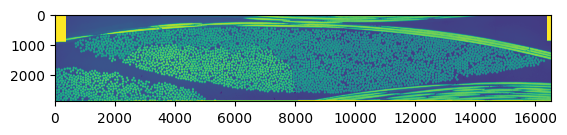

In [65]:
plt.figure(figsize=(20,5))
plt.imshow(bin > 0)
plt.show()

plt.imshow(img)
plt.show()


3456


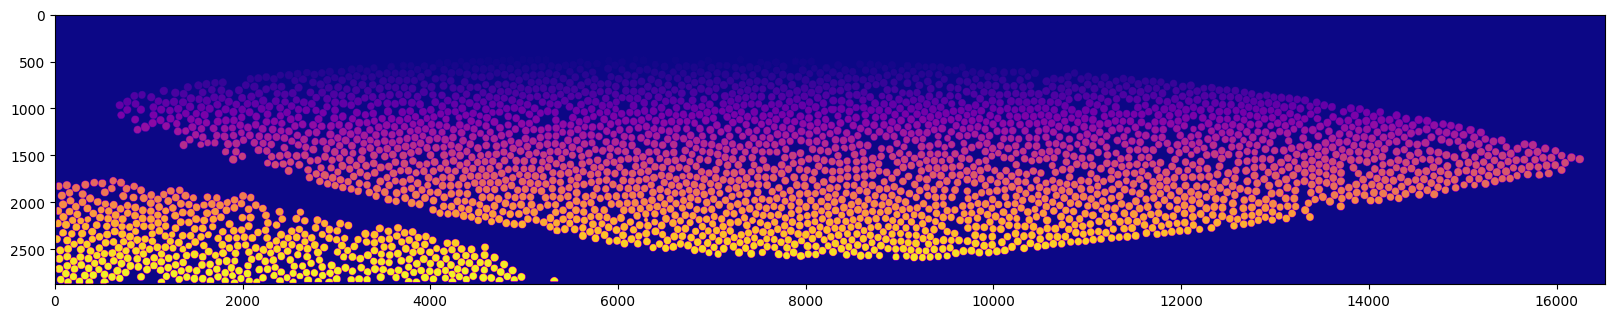

In [66]:
inst = label(bin)
plt.figure(figsize=(20,5))
plt.imshow(inst,cmap="plasma")
inst =inst.astype(np.int16)
print(len(np.unique(inst)))

0 16514 0 2873


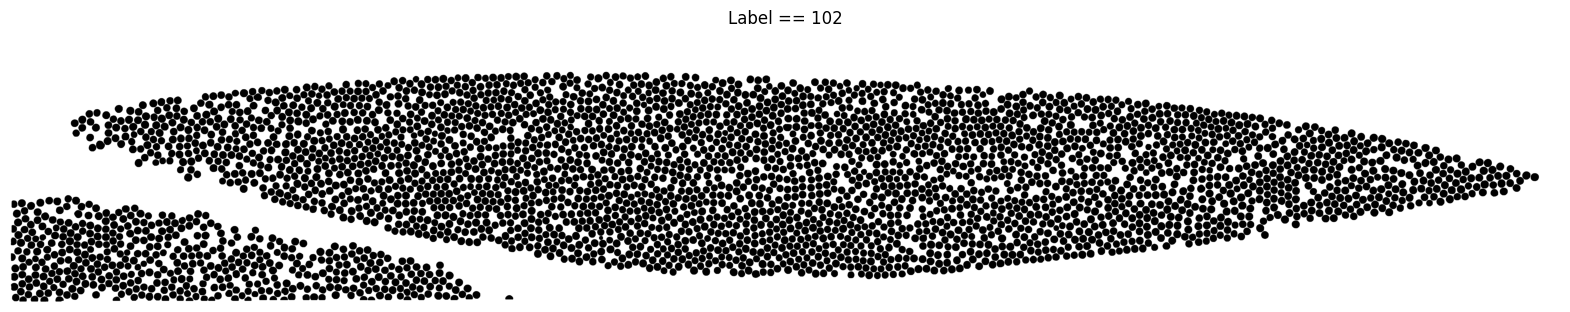

In [67]:
plt.figure(figsize=(20, 5))

mask = inst == 0

ys, xs = np.where(mask)


x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

print(x_min,x_max,y_min,y_max)

plt.imshow(mask, cmap="gray")
plt.title("Label == 102")
plt.axis("off")
plt.show()

In [68]:
inst = np.array(inst, dtype=np.uint16)
Image.fromarray(inst, mode='I;16').save(instance_path)